## Install Library

## All import

In [1]:
import pandas as pd
import numpy as np
import json
import re
import time
import seaborn as sns
import openai
import os
from typing import List, Dict, Any, Tuple
from sentence_transformers import SentenceTransformer
from openai import OpenAI
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from dotenv import load_dotenv
from sentence_transformers import SentenceTransformer
from pyvi.ViTokenizer import tokenize
from pinecone import Pinecone, ServerlessSpec
from langchain_core.documents import Document
from typing import TypedDict, Literal

## API Keys

In [2]:
load_dotenv()

pinecone_api_key = os.getenv("PINECONE_API_KEY")
tavily_api_key = os.getenv("TAVILY_API_KEY")

## Setup the Datasets

In [3]:
df = pd.read_csv("../data/csv/techcombank_faq.csv")
df.head()

,question,answer
0,Tôi phải làm gì khi bị mất thẻ?,"Hướng dẫn khi mất thẻ: Khi bị mất thẻ, điều đầ..."
1,Techcombank có chức năng thanh toán bằng mã QR...,Thanh toán bằng mã QR qua Techcombank Mobile H...
2,Dịch vụ chuyển khoản nhanh 24/7 có gì khác so ...,Chuyển tiền 24/7 và chuyển tiền liên ngân hàng...
3,Tôi muốn nâng hạn mức chuyển khoản?,Cách để nâng hạn mức chuyển khoản qua Techcomb...
4,Thông tin sinh trắc học của tôi sẽ sử dụng vào...,"Bắt đầu từ ngày 01/07/2024, Techcombank sẽ áp ..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  261 non-null    object
 1   answer    261 non-null    object
dtypes: object(2)
memory usage: 4.2+ KB


In [5]:
df["combined_text"] = (
    "Question: " + df["question"].astype(str) + "\n" +
    "Answer: " + df["answer"].astype(str)
)
df.head()

,question,answer,combined_text
0,Tôi phải làm gì khi bị mất thẻ?,"Hướng dẫn khi mất thẻ: Khi bị mất thẻ, điều đầ...",Question: Tôi phải làm gì khi bị mất thẻ?\nAns...
1,Techcombank có chức năng thanh toán bằng mã QR...,Thanh toán bằng mã QR qua Techcombank Mobile H...,Question: Techcombank có chức năng thanh toán ...
2,Dịch vụ chuyển khoản nhanh 24/7 có gì khác so ...,Chuyển tiền 24/7 và chuyển tiền liên ngân hàng...,Question: Dịch vụ chuyển khoản nhanh 24/7 có g...
3,Tôi muốn nâng hạn mức chuyển khoản?,Cách để nâng hạn mức chuyển khoản qua Techcomb...,Question: Tôi muốn nâng hạn mức chuyển khoản?\...
4,Thông tin sinh trắc học của tôi sẽ sử dụng vào...,"Bắt đầu từ ngày 01/07/2024, Techcombank sẽ áp ...",Question: Thông tin sinh trắc học của tôi sẽ s...


In [6]:
print(df["combined_text"].iloc[6])

Question: Làm thế nào để tôi biết thiết bị của mình có hỗ trợ đọc thông tin CCCD gắn chip?
Answer: Khi thao tác theo hướng dẫn trên Techcombank Mobile để bổ sung thông tin sinh trắc học, tại màn hình giới thiệu, quý khách bấm vào "Bổ sung ngay" hệ thống sẽ tự động nhận diện thiết bị di động của quý khách có đủ điều kiện đọc chip trên CCCD (NFC). Nếu xuất hiện màn hình thông báo "Vui lòng ghé chi nhánh để bổ sung thông tin" thể hiện thiết bị di động của quý khách không hỗ trợ công nghệ này.


In [8]:
documents = df["combined_text"].tolist()
documents

['Question: Tôi phải làm gì khi bị mất thẻ?\nAnswer: Hướng dẫn khi mất thẻ: Khi bị mất thẻ, điều đầu tiên bạn nên làm là khóa thẻ để đảm bảo an toàn cho tài khoản của bạn với các cách sau: Cách 1: Khóa thẻ tạm thời qua Techcombank Mobile Bước 1: Đăng nhập Techcombank Mobile Bước 2: Chọn mục Tài khoản và Thẻ tại trang chủ Bước 3: Lựa chọn Thẻ cần khóa Bước 4: Chọn Khóa thẻ (Thẻ bị khóa sẽ không thể thực hiện các giao dịch thanh toán trực tuyến, quẹt thẻ tại POS và rút tiền tại ATM) Cách 2: Gọi điện lên tổng đài Khách hàng cá nhân 1800 588 822 (miễn phí) để yêu cầu khóa thẻ.',
 'Question: Techcombank có chức năng thanh toán bằng mã QR không?\nAnswer: Thanh toán bằng mã QR qua Techcombank Mobile Hiện tại tính năng thanh toán qua QR code của Techcombank được chấp nhận thanh toán tại tất cả các đơn vị thanh toán của VN PAY và mPOS. Quý khách cần sử dụng ứng dụng Techcombank Mobile để có thể trải nghiệm tính năng thanh toán bằng QRcode này: Bước 1: Đăng nhập Techcombank Mobile Bước 2: Chọn m

In [9]:
len(documents)

261

In [3]:
model = SentenceTransformer("AITeamVN/Vietnamese_Embedding_v2")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [10]:
doc_embs = model.encode(documents, normalize_embeddings=True)

In [11]:
doc_embs

array([[ 0.00051757,  0.03529464, -0.05147276, ..., -0.00461177,
         0.00688695, -0.03883111],
       [-0.04644153,  0.01942158,  0.00514263, ..., -0.00289443,
        -0.00651458, -0.04510192],
       [-0.03956217,  0.00752462, -0.02680258, ..., -0.01146036,
        -0.01569423, -0.07240598],
       ...,
       [-0.01529167,  0.00960657, -0.02503695, ..., -0.02616426,
        -0.03034284,  0.02690589],
       [-0.00594889, -0.02891395, -0.04256698, ...,  0.01636932,
         0.00371898, -0.00549758],
       [-0.03749713, -0.01342302, -0.04976813, ..., -0.04546791,
        -0.02399261,  0.00210002]], shape=(261, 1024), dtype=float32)

In [12]:
print(len(doc_embs[0]))

1024


In [13]:
from sklearn.metrics.pairwise import cosine_similarity

query = "Tôi muốn nâng hạn mức chuyển khoản?"

q_emb = model.encode([query], normalize_embeddings=True)

scores = cosine_similarity(q_emb, doc_embs)[0]

top_k = 3
top_indices = scores.argsort()[-top_k:][::-1]

for i in top_indices:
    print(documents[i])
    print("Score:", scores[i])
    print("------")

Question: Tôi muốn nâng hạn mức chuyển khoản thì phải làm thế nào?
Answer: Hạn mức chuyển khoản của bạn được mặc định là 500.000.000VNĐ/ngày trên Techcombank Mobile, áp dụng với chuyển nhanh 24/7 và chuyển liên ngân hàng. Trong trường hợp muốn chuyển với số tiền lớn hơn nhưng không vượt quá 5 tỷ VNĐ, bạn có thể đăng nhập Techcombank Mobile để thay đổi hạn mức. Hạn mức mới thay đổi sẽ có hiệu lực trong vòng 30 ngày, sau đó sẽ trở lại hạn mức mặc định 500 triệu đồng/ngày. Thanh toán và chuyển khoản bằng mã QR:
Score: 0.72998655
------
Question: Tôi muốn nâng hạn mức chuyển khoản?
Answer: Cách để nâng hạn mức chuyển khoản qua Techcombank Mobile Hạn mức chuyển khoản của bạn được mặc định là 500.000.000VNĐ/ngày trên Techcombank Mobile, áp dụng với chuyển nhanh 24/7 và chuyển liên ngân hàng. Trong trường hợp muốn chuyển với số tiền lớn hơn nhưng không vượt quá 5 tỷ VNĐ, bạn có thể đăng nhập Techcombank Mobile để thay đổi hạn mức. Hạn mức mới thay đổi sẽ có hiệu lực trong vòng 30 ngày, sau đó

## Store Vector DB

In [4]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [5]:
from pinecone import Pinecone
pc = Pinecone(api_key=pinecone_api_key)

In [6]:
pc

In [17]:
from pinecone import ServerlessSpec

index_name = "agentic-rag-tcb"

if index_name not in pc.list_indexes().names():
    pc.create_index(
        name=index_name,
        dimension=1024,
        metric="cosine",
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1"
        )
    )

index = pc.Index(index_name)

In [18]:
docs = []
for _, row in df.iterrows():
    docs.append(
        Document(
            page_content=row["combined_text"],
            metadata={
                "question": row["question"],
                "source": "techcombank_faq"
            }
        )
    )

In [19]:
docs

[Document(metadata={'question': 'Tôi phải làm gì khi bị mất thẻ?', 'source': 'techcombank_faq'}, page_content='Question: Tôi phải làm gì khi bị mất thẻ?\nAnswer: Hướng dẫn khi mất thẻ: Khi bị mất thẻ, điều đầu tiên bạn nên làm là khóa thẻ để đảm bảo an toàn cho tài khoản của bạn với các cách sau: Cách 1: Khóa thẻ tạm thời qua Techcombank Mobile Bước 1: Đăng nhập Techcombank Mobile Bước 2: Chọn mục Tài khoản và Thẻ tại trang chủ Bước 3: Lựa chọn Thẻ cần khóa Bước 4: Chọn Khóa thẻ (Thẻ bị khóa sẽ không thể thực hiện các giao dịch thanh toán trực tuyến, quẹt thẻ tại POS và rút tiền tại ATM) Cách 2: Gọi điện lên tổng đài Khách hàng cá nhân 1800 588 822 (miễn phí) để yêu cầu khóa thẻ.'),
 Document(metadata={'question': 'Techcombank có chức năng thanh toán bằng mã QR không?', 'source': 'techcombank_faq'}, page_content='Question: Techcombank có chức năng thanh toán bằng mã QR không?\nAnswer: Thanh toán bằng mã QR qua Techcombank Mobile Hiện tại tính năng thanh toán qua QR code của Techcombank

In [4]:
from langchain.embeddings.base import Embeddings

class CustomEmbedding(Embeddings):
    def embed_documents(self, texts):
        return model.encode(texts).tolist()

    def embed_query(self, text):
        return model.encode([text])[0].tolist()

In [ ]:
from langchain_pinecone import PineconeVectorStore

docsearch = PineconeVectorStore.from_documents(
    documents=docs,
    embedding=CustomEmbedding(),
    index_name=index_name,
)

In [5]:
# load Existing index
from langchain_pinecone import PineconeVectorStore

index_name = "agentic-rag-tcb"

# embed each chunk and upsert the embeddings into your Pinecone index
collection = PineconeVectorStore.from_existing_index(
    index_name=index_name,
    embedding=CustomEmbedding()
)

In [ ]:
from llama_cpp import llama_supports_gpu_offload
print(llama_supports_gpu_offload())

False


In [6]:
retriever = collection.as_retriever(search_type="similarity", search_kwargs={"k":3})

In [29]:
query="Khi sử dụng thẻ tín dụng quốc tế Techcombank Visa để rút tiền mặt tại ATM của ngân hàng khác, tôi có phải trả phí không? Mức phí là bao nhiêu?"
retriever_docs = retriever.invoke(query)

q_emb = model.encode([query], normalize_embeddings=True)
doc_embs_query = model.encode([doc.page_content for doc in retriever_docs], normalize_embeddings=True)
scores = cosine_similarity(q_emb, doc_embs_query)[0]

for doc, score in zip(retriever_docs, scores):
    print(f"Content: {doc}")
    print(f"Score: {score:.4f}")
    print("------")

Content: page_content='Question: Khi sử dụng thẻ tín dụng quốc tế Techcombank Visa để rút tiền mặt tại ATM của ngân hàng khác, tôi có phải trả phí không? Mức phí là bao nhiêu?
Answer: Với giao dịch rút tiền bằng thẻ tín dụng quốc tế Techcombank Visa tại ATM của ngân hàng khác, Techcombank sẽ thu mức phí là 4% giá trị giao dịch và tối thiểu là 100.000 đồng (đã bao gồm 10%VAT). Ngoài ra, Quý khách hàng có thể chịu thêm một mức phí do ngân hàng chủ quản ATM thu, mức phí này là khác nhau tùy theo quy định của từng ngân hàng.' metadata={'question': 'Khi sử dụng thẻ tín dụng quốc tế Techcombank Visa để rút tiền mặt tại ATM của ngân hàng khác, tôi có phải trả phí không? Mức phí là bao nhiêu?', 'source': 'techcombank_faq'}
Score: 0.7618
------
Content: page_content='Question: Khi sử dụng thẻ tín dụng quốc tế Vietnam Airlines Techcombank Visa để rút tiền mặt tại ATM của ngân hàng khác, tôi có phải trả phí không? Mức phí là bao nhiêu?
Answer: Với giao dịch rút tiền bằng thẻ tín dụng quốc tế Tech

## Setup WebSearch

In [6]:
from langchain_tavily import TavilySearch

tavily_search = TavilySearch(topic="general", max_results=3)

query = "Rượu chuối hột là rượu gì?"

results = tavily_search.invoke({"query": query})

results['results'][1]['content']

'# Rượu chuối hột là gì? Cách ngâm rượu chuối hột đúng, đơn giản. ## Rượu chuối hột là loại rượu Việt Nam ngâm quả của loài chuối, có nhiều tác dụng đối với sức khỏe. Hướng dẫn ngâm rượu chuối hột đúng cách. ### 1 Tìm hiểu về rượu chuối hột. ### 2 Hướng dẫn ngâm rượu chuối hột đúng cách. Chọn nguyên liệu để làm rượu chuối hột. ### 2 Cách ngâm rượu chuối hột. Cho chuối hột và rượu vào bình. ### 3 Tác dụng của rượu chuối hột. ### 4 Lưu ý khi uống rượu chuối hột. Thử làm chè chuối nước cốt dừa béo thơm, ăn là ghiền cho ngày hè. Mách bạn 2 cách làm kem chuối nước cốt dừa béo thơm vị dừa. 3 cách làm mứt chuối dẻo ngày Tết thơm béo, dễ làm, ăn là mê. Cách làm bánh crepe lá dứa nhân kem chuối mềm thơm, ngọt ngào cho cả nhà.'

## Setup Groq API - Model

In [36]:
!pip install langchain-groq


   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   -------------------- ------------------- 1/2 [langchain-groq]
   ---------------------------------------- 2/2 [langchain-groq]



In [ ]:
# import os
# from dotenv import load_dotenv
# from huggingface_hub import InferenceClient

# load_dotenv()

# client_llm = InferenceClient(
#     api_key=os.environ["HF_TOKEN"],
# )

# def get_llm_response(prompt: str) -> str:
#     completion = client_llm.chat.completions.create(
#         model="meta-llama/Llama-3.3-70B-Instruct:groq",
#         messages=[
#             {
#                 "role": "user",
#                 "content": prompt
#             }
#         ],
#     )
#     return completion.choices[0].message.content

# prompt = "Kiên Giang có đại diện biển số xe số mấy?"
# response = get_llm_response(prompt)
# print(response)
# from sympy import content
# from langchain_core.messages import HumanMessage
# from langchain_groq import ChatGroq
# import os
# load_dotenv()

# def get_llm_response(prompt: str) -> str:
# # load LLM
#     client_llm = ChatGroq(
#         model="llama-3.3-70b-versatile",
#         api_key=os.environ["GROQ_API_KEY"]
#     )
#     response = client_llm.invoke([HumanMessage(content=prompt)])
#     return response.content

# prompt = "Kiên Giang có gì vui?"
# response = get_llm_response(prompt)
# print(response)

Kiên Giang có biển số xe 68.


In [7]:
import os
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, AIMessage
from langchain_groq import ChatGroq

load_dotenv()

client_llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.environ["GROQ_API_KEY"]
)

chat_history = []

def get_llm_response(prompt: str) -> str:
    # Build messages với history
    messages = []
    for msg in chat_history:
        messages.append(msg)

    messages.append(HumanMessage(content=prompt))

    response = client_llm.invoke(messages)
    answer = response.content

    # Lưu vào history
    chat_history.append(HumanMessage(content=prompt))
    chat_history.append(AIMessage(content=answer))

    return answer


# Test
print(get_llm_response("Kiên Giang có gì vui?"))
print("---")
print(get_llm_response("Còn ẩm thực thì sao?"))        # nhớ đang nói về Kiên Giang
print("---")
print(get_llm_response("Tóm tắt lại những gì bạn vừa nói"))  # nhớ cả 2 câu trước

# Xem history
print("\n=== Chat history ===")
for msg in chat_history:
    role = "User" if isinstance(msg, HumanMessage) else "Assistant"
    print(f"{role}: {msg.content}\n")

# Reset session mới
# chat_history.clear()

Kiên Giang là một tỉnh thuộc vùng Đồng bằng sông Cửu Long, Việt Nam. Đây là một điểm đến thú vị với nhiều cảnh quan thiên nhiên đẹp, di tích lịch sử, và văn hóa phong phú. Dưới đây là một số điều thú vị bạn có thể khám phá khi đến Kiên Giang:

1. **Đảo Phú Quốc**: Đây là hòn đảo lớn nhất Việt Nam, nổi tiếng với những bãi biển đẹp như Bãi Dài, Bãi Sao, và Bãi Khem. Du khách có thể tận hưởng hoạt động lặn với ống thở, đi bộ dưới biển, hoặc simplemente thư giãn trên bãi biển.
2. **Rừng quốc gia U Minh Thượng**: Đây là một khu bảo tồn thiên nhiên với hệ động thực vật phong phú. Du khách có thể tham gia các hoạt động như đi bộ đường dài,观察 động vật hoang dã, và tìm hiểu về hệ sinh thái của rừng ngập mặn.
3. **Thành phố Rạch Giá**: Là thành phố lớn nhất của tỉnh Kiên Giang, Rạch Giá có nhiều di tích lịch sử như chùa Tam Bảo, chùa Kim Cương, và nhà thờ Rạch Giá. Du khách cũng có thể thăm các chợ truyền thống như chợ Rạch Giá và chợ Long Xuyên.
4. **Đảo Hải Tặc (Kiên Hải)**: Đây là một quần đả

## Build the Pineline

In [8]:
class GraphState(TypedDict):
    query: str
    context: str
    prompt: str
    source: str
    is_relevant: str
    iteration_count: str
    augmented_prompt: str
    answer: str

In [ ]:
from langgraph.graph import StateGraph, MessagesState, START, END

def retrieve_context_q_n_a(state):
    """Retrieve top documents from Pinecone (tcb_qna) based on query."""
    print("Retrieving context")
    query = state["query"]
    results = collection.similarity_search(query, k=3)
    context = "\n".join([doc.page_content for doc in results])
    state["context"] = context
    state["source"] = "Techcombank Support QA Collection"
    print("Context")

    return state


def tavily_web_search(state):
    """Perform web search using TavilySearch API."""
    print("Performing web search")
    tavily_search = TavilySearch(topic="general", max_results=1)
    query = state["query"]
    results = tavily_search.invoke({"query": query})
    state["context"] = results['results'][0]['content']
    print("Web search completed")

    return state

def router(state: GraphState) -> Literal[
    "Retrieve_QnA", "Web_Search"
]:
    """Agentic router: decides which retrieval method to use"""
    query = state["query"]

    # A lightweight decision LLM - u can replace this with GPT-3.5 or any other model
    decision_prompt = f"""
    You are a routing agent. Based on the user query, decide where to look for information.

    Options:
    - Retrieve_QnA: If it's a Techcombank customer service question that can be answered from a QnA collection, choose this.
    - Web_Search: If it's a general question or requires up-to-date information, choose this.
    
    Query: "{query}"

    Respond ONLY with one of: Retrieve_QnA, Web_Search
    """

    router_decision = get_llm_response(decision_prompt).strip()
    print(f"Router decision: {router_decision}")
    
    print(router_decision)

    state["source"] = router_decision
    return state

def route_decision(state: GraphState) -> str:
    return state["source"]

def check_context_relevance(state: GraphState):
    """Determine whether the retrieved context is relevant or not."""
    print("Context relevance check")
    query = state["query"]
    context = state["context"]
    relevance_prompt = f"""
        Check the context below to see if the context is relevant to user query or not.
        ####
        Context:
        {context}
        ####
        User Query: {query}

        Options:
        - Yes: if the context is relevant
        - No: if the context is not relevant

        Please answer with only Yes or No.
        """
    relevance_decision_value = get_llm_response(relevance_prompt).strip()
    print(f"Relevance decision: {relevance_decision_value}")
    state["is_relevant"] = relevance_decision_value

    return state

def relevance_decision(state: GraphState) -> str:
    iteration_count = state.get("iteration_count", 0)
    iteration_count += 1
    state["iteration_count"] = iteration_count
    ## Limitting to max 2 iterations
    if iteration_count >= 2:
        print("Max iterations reached, forcing 'yes'")
        state["is_relevant"] = "Yes"
    return state["is_relevant"]
    
def build_prompt(state: GraphState) -> GraphState:
    """Build the augmented prompt using retrieved context."""
    query = state["query"]
    context = state["context"]
    source = state.get("source", "Unknown")
    state["augmented_prompt"] = f"""You are a helpful assistant. Use the context below to answer the user's question.
    Source: {source}
    Context:
    {context}
    Question: {query}
    Answer:"""
    return state

def call_llm(state: GraphState) -> GraphState:
    """Generate final answer using the augmented prompt."""
    prompt = state["augmented_prompt"]
    state["answer"] = get_llm_response(prompt)
    return state

## Define state Graph

In [10]:
workflow = StateGraph(GraphState)

workflow.add_node("Router", router)
workflow.add_node("Retrieve_QnA", retrieve_context_q_n_a)
workflow.add_node("Web_Search", tavily_web_search)
workflow.add_node("Relevant_Context_Checker", check_context_relevance)
workflow.add_node("Augment", build_prompt)
workflow.add_node("Generate", call_llm)

workflow.add_edge(START, "Router")
workflow.add_conditional_edges(
    "Router",
    route_decision,
    {
        "Retrieve_QnA": "Retrieve_QnA",
        "Web_Search": "Web_Search"
    }
)
workflow.add_edge("Retrieve_QnA", "Relevant_Context_Checker")
workflow.add_edge("Web_Search", "Relevant_Context_Checker")

workflow.add_conditional_edges(
    "Relevant_Context_Checker",
    relevance_decision,
    {
        "Yes": "Augment",
        "No": "Web_Search"
    }
)
workflow.add_edge("Augment", "Generate")
workflow.add_edge("Generate", END)

agentic_rag = workflow.compile()

## Visualize state graph

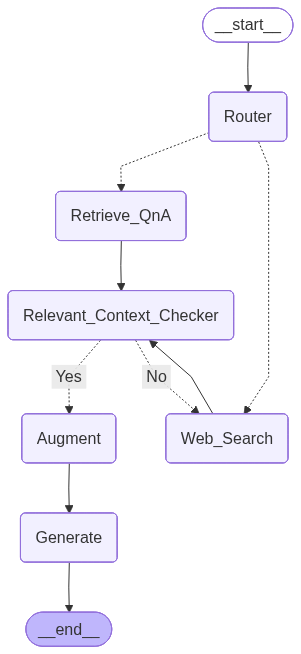

In [11]:
from IPython.display import Image, display
display(Image(agentic_rag.get_graph().draw_mermaid_png()))

## Test the Agentic RAG pineline

In [12]:
def response_answer(query:str) -> str:
    input_state = {"query": query}

    for step in agentic_rag.stream(input_state):
        for key, value in step.items():
            print(f"Finished running {key}:")
    return print(value["answer"])

In [17]:
response_answer('Xin chào, tôi là Chis.')

Router decision: Retrieve_QnA
Retrieve_QnA
Finished running Router:
Retrieving context
Context
Finished running Retrieve_QnA:
Context relevance check
Relevance decision: No
Finished running Relevant_Context_Checker:
Performing web search
Web search completed
Finished running Web_Search:
Context relevance check


RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kmnnpn8behgac47zzqmx8ayk` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99390, Requested 4470. Please try again in 55m35.04s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [ ]:
response_answer('Bạn hãy cho tôi biết tôi tên gì?')

Router decision: Retrieve_QnA
Retrieve_QnA
Finished running Router:
Retrieving context
Context
Finished running Retrieve_QnA:
Context relevance check
Relevance decision: Yes
Finished running Relevant_Context_Checker:
Finished running Augment:
Finished running Generate:
Xin lỗi, nhưng tôi không thể cung cấp thông tin về tên của bạn vì không có dữ liệu liên quan trong hệ thống của chúng tôi. Nếu bạn quên tên đăng nhập, bạn có thể sử dụng tính năng Quên tên đăng nhập để tạo mới mật khẩu đăng nhập bằng cách cung cấp thông tin CMND/CCCD, số thẻ, mã PIN thẻ và mã xác thực gửi về số điện thoại đã đăng ký. Nếu bạn cần hỗ trợ thêm, vui lòng liên hệ với chúng tôi.


In [16]:
response_answer('ngân hàng tcb có mấy chi nhánh')

Router decision: Web_Search
Web_Search
Finished running Router:
Performing web search
Web search completed
Finished running Web_Search:
Context relevance check


RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kmnnpn8behgac47zzqmx8ayk` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 98279, Requested 4200. Please try again in 35m41.855999999s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}